# Temporal Feature Engineering

**Goal:** Transform raw crash timestamps into features that capture *how the past predicts the future*.

The original model used `hour`, `month`, and `day_of_week` as static labels.
This notebook adds **lag features** and **rolling metrics** that let the model understand momentum:

> *"Injuries have been rising for 3 months straight → current month is likely elevated too."*

---
### What we're adding and why

| Feature | Type | What it captures |
|---------|------|-----------------|
| `lag_1`, `lag_3`, `lag_12` | Lag | Injuries in prior months |
| `rolling_mean_3m` | Rolling | Short-term injury momentum |
| `rolling_mean_6m` | Rolling | Medium-term trend |
| `rolling_std_3m` | Rolling | Recent volatility / instability |
| `month_over_month_pct` | Delta | Rate of change (acceleration) |
| `is_peak_season` | Binary | Summer/fall risk flag |
| `injury_rate_per_crash` | Ratio | Crash severity trend |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded')

Libraries loaded


## Step 1: Build Monthly Aggregated Dataset

We aggregate the crash-level data to monthly totals first, then engineer features on that monthly series.

In [ ]:
df = pd.read_csv('/Users/Marcy_Student/Desktop/Capstone/Pedestrian-Injury-Risk-Predictor-Expanded/Data/cleaned_crash_data.csv')
df['CRASH DATE'] = pd.to_datetime(df['CRASH DATE'], errors='coerce')

# Monthly aggregations: injuries, crash count, injury rate
monthly = (
    df.set_index('CRASH DATE')
      .resample('ME')
      .agg(
          total_injuries=('NUMBER OF PEDESTRIANS INJURED', 'sum'),
          total_crashes=('NUMBER OF PEDESTRIANS INJURED', 'count')
      )
)

monthly = monthly[monthly['total_injuries'] > 0].copy()
monthly['injury_rate_per_crash'] = (monthly['total_injuries'] / 
                                     monthly['total_crashes'].replace(0, np.nan))

print(f'Monthly records: {len(monthly)}')
monthly.tail()

Monthly records: 48


,total_injuries,total_crashes,injury_rate_per_crash
CRASH DATE,,,
2025-08-31,535,6721,0.079601
2025-09-30,761,7247,0.105009
2025-10-31,887,7230,0.122683
2025-11-30,840,6748,0.124481
2025-12-31,161,1073,0.150047


## Step 2: Lag Features

**What is a lag feature?**

A lag feature is the value of a variable from a previous time step.
- `lag_1` = injuries last month
- `lag_3` = injuries 3 months ago
- `lag_12` = injuries same month last year (captures year-over-year patterns)

This is what allows the model to say: *"Last month was high, so this month is probably elevated too."*

In [3]:
# Lag features on total_injuries
monthly['lag_1']  = monthly['total_injuries'].shift(1)
monthly['lag_3']  = monthly['total_injuries'].shift(3)
monthly['lag_6']  = monthly['total_injuries'].shift(6)
monthly['lag_12'] = monthly['total_injuries'].shift(12)  # same month last year

print('Lag features added:')
print(monthly[['total_injuries', 'lag_1', 'lag_3', 'lag_12']].tail(8).round(1))

Lag features added:
            total_injuries  lag_1  lag_3  lag_12
CRASH DATE                                      
2025-05-31             741  704.0  697.0   745.0
2025-06-30             636  741.0  712.0   694.0
2025-07-31             606  636.0  704.0   579.0
2025-08-31             535  606.0  741.0   564.0
2025-09-30             761  535.0  636.0   657.0
2025-10-31             887  761.0  606.0   813.0
2025-11-30             840  887.0  535.0   959.0
2025-12-31             161  840.0  761.0  1031.0


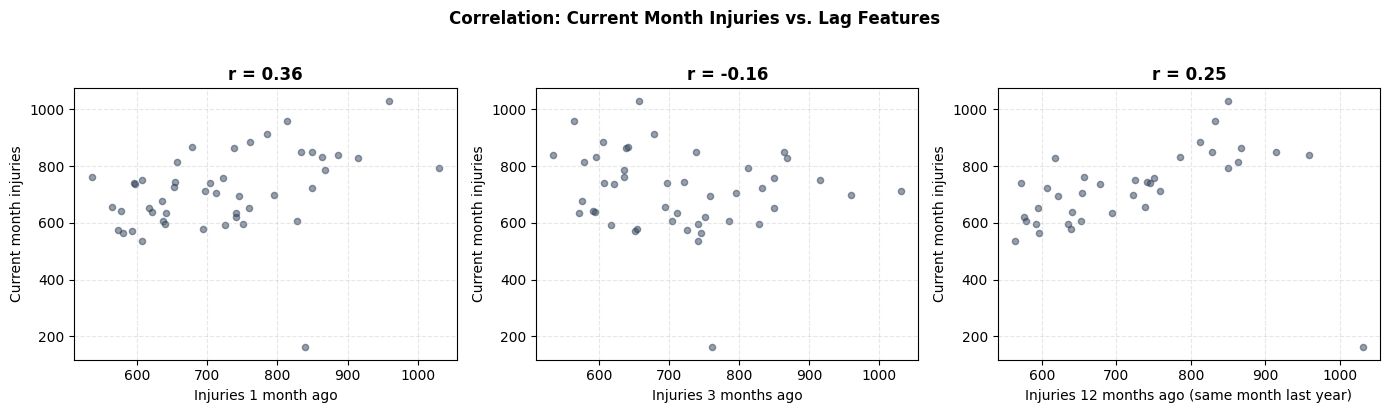


Interpretation: Higher correlation = that lag is more predictive
lag_12 (same month last year) often shows strong correlation due to seasonality


In [4]:
# Visualize: how correlated is current month with lag_1 vs lag_12?
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, lag_col, lag_label in zip(
    axes, 
    ['lag_1', 'lag_3', 'lag_12'],
    ['1 month ago', '3 months ago', '12 months ago (same month last year)']
):
    plot_data = monthly[['total_injuries', lag_col]].dropna()
    corr = plot_data['total_injuries'].corr(plot_data[lag_col])
    
    ax.scatter(plot_data[lag_col], plot_data['total_injuries'],
               alpha=0.5, color='#2E4057', s=20)
    ax.set_xlabel(f'Injuries {lag_label}')
    ax.set_ylabel('Current month injuries')
    ax.set_title(f'r = {corr:.2f}', fontsize=12, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.3)

fig.suptitle('Correlation: Current Month Injuries vs. Lag Features', 
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('\nInterpretation: Higher correlation = that lag is more predictive')
print('lag_12 (same month last year) often shows strong correlation due to seasonality')

## Step 3: Rolling Window Features

**Rolling mean** = average of the last N months → smoothed momentum signal

**Rolling std** = standard deviation of the last N months → captures recent volatility

These features don't use future data (they're computed from past values only), so they're safe to include in models without data leakage.

In [5]:
# Rolling means and std (shift(1) prevents data leakage — uses only past values)
monthly['rolling_mean_3m'] = (
    monthly['total_injuries'].shift(1).rolling(window=3).mean()
)
monthly['rolling_mean_6m'] = (
    monthly['total_injuries'].shift(1).rolling(window=6).mean()
)
monthly['rolling_std_3m'] = (
    monthly['total_injuries'].shift(1).rolling(window=3).std()
)

print('Rolling features added:')
print(monthly[['total_injuries', 'rolling_mean_3m', 
               'rolling_mean_6m', 'rolling_std_3m']].tail(8).round(1))

Rolling features added:
            total_injuries  rolling_mean_3m  rolling_mean_6m  rolling_std_3m
CRASH DATE                                                                  
2025-05-31             741            704.3            816.3             7.5
2025-06-30             636            719.0            780.0            19.5
2025-07-31             606            693.7            714.2            53.3
2025-08-31             535            661.0            682.7            70.9
2025-09-30             761            592.3            655.7            51.9
2025-10-31             887            634.0            663.8           115.6
2025-11-30             840            727.7            694.3           178.4
2025-12-31             161            829.3            710.8            63.7


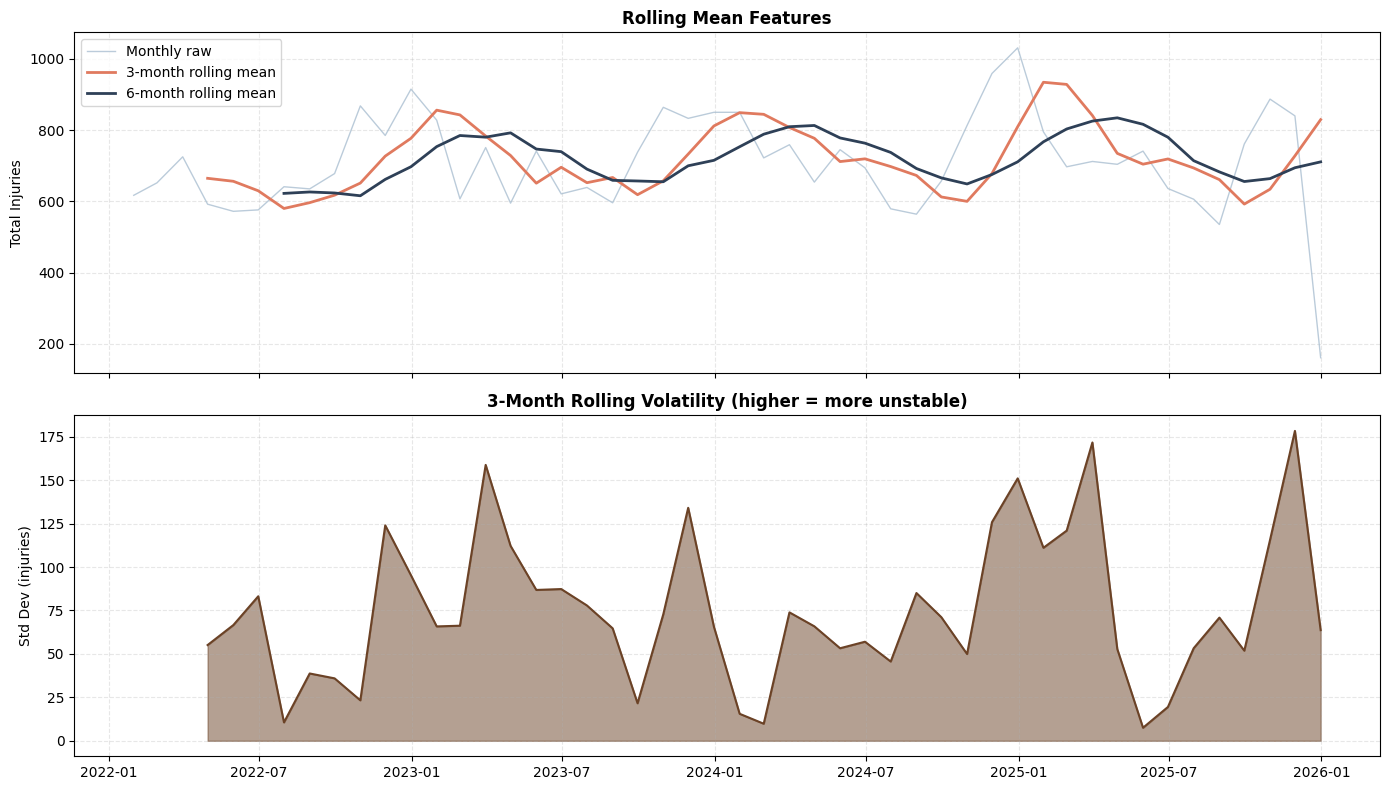

In [6]:
# Visualize rolling features over time
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Rolling means
axes[0].plot(monthly.index, monthly['total_injuries'], 
             color='#AABFD1', linewidth=1.0, alpha=0.8, label='Monthly raw')
axes[0].plot(monthly.index, monthly['rolling_mean_3m'],
             color='#E07A5F', linewidth=2.0, label='3-month rolling mean')
axes[0].plot(monthly.index, monthly['rolling_mean_6m'],
             color='#2E4057', linewidth=2.0, label='6-month rolling mean')
axes[0].set_ylabel('Total Injuries')
axes[0].set_title('Rolling Mean Features', fontweight='bold')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.3)

# Rolling std (volatility)
axes[1].fill_between(monthly.index, monthly['rolling_std_3m'], 
                     alpha=0.5, color='#6B4226')
axes[1].plot(monthly.index, monthly['rolling_std_3m'],
             color='#6B4226', linewidth=1.5)
axes[1].set_ylabel('Std Dev (injuries)')
axes[1].set_title('3-Month Rolling Volatility (higher = more unstable)', fontweight='bold')
axes[1].grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

## Step 4: Momentum and Rate-of-Change Features

In [7]:
# Month-over-month % change
monthly['mom_pct_change'] = monthly['total_injuries'].pct_change() * 100

# Year-over-year % change
monthly['yoy_pct_change'] = monthly['total_injuries'].pct_change(12) * 100

# Rising/falling momentum flag
monthly['momentum_3m'] = (
    (monthly['total_injuries'] > monthly['rolling_mean_3m'])
    .astype(int)
    .map({1: 'Above 3m avg (rising)', 0: 'Below 3m avg (falling)'})
)

# Recent YoY comparison
print('Recent year-over-year change:')
recent = monthly[['total_injuries', 'yoy_pct_change']].tail(6)
for date, row in recent.iterrows():
    direction = '↑' if row['yoy_pct_change'] > 0 else '↓'
    print(f'  {date.strftime("%Y-%m")} : {row["total_injuries"]:.0f} injuries  '
          f'({direction} {abs(row["yoy_pct_change"]):.1f}% vs same month last year)')

Recent year-over-year change:
  2025-07 : 606 injuries  (↑ 4.7% vs same month last year)
  2025-08 : 535 injuries  (↓ 5.1% vs same month last year)
  2025-09 : 761 injuries  (↑ 15.8% vs same month last year)
  2025-10 : 887 injuries  (↑ 9.1% vs same month last year)
  2025-11 : 840 injuries  (↓ 12.4% vs same month last year)
  2025-12 : 161 injuries  (↓ 84.4% vs same month last year)


## Step 5: Calendar-Based Temporal Features

These are categorical flags derived from the date that help the model learn structural patterns.

In [8]:
monthly['month_num']     = monthly.index.month
monthly['quarter']       = monthly.index.quarter
monthly['year']          = monthly.index.year

# Peak season flag: Jun–Oct (summer/fall = historically higher injury months)
monthly['is_peak_season'] = monthly['month_num'].isin([6, 7, 8, 9, 10]).astype(int)

# Winter flag: Dec–Feb (historically lower)
monthly['is_winter']      = monthly['month_num'].isin([12, 1, 2]).astype(int)

# Verify: do peak season months actually have higher injuries?
season_comp = monthly.groupby('is_peak_season')['total_injuries'].agg(['mean', 'median'])
season_comp.index = ['Off-peak (Nov-May)', 'Peak season (Jun-Oct)']
print('Average monthly injuries by season:')
print(season_comp.round(1))

Average monthly injuries by season:
                        mean  median
Off-peak (Nov-May)     729.8   741.0
Peak season (Jun-Oct)  679.4   640.0


## Step 6: Feature Correlation Matrix

Check which temporal features are most correlated with `total_injuries`.
Highly correlated features are the most useful for prediction.

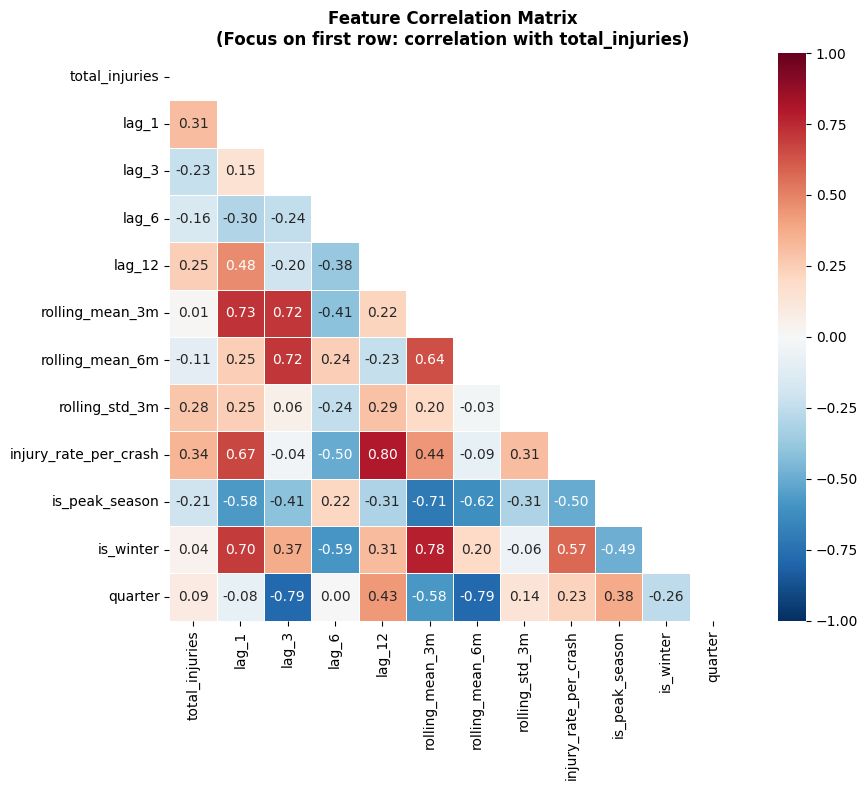


Feature correlation with total_injuries (ranked):
  injury_rate_per_crash     +0.342  ██████
  lag_1                     +0.308  ██████
  rolling_std_3m            +0.279  █████
  lag_12                    +0.249  ████
  lag_3                     -0.229  ████
  is_peak_season            -0.209  ████
  lag_6                     -0.159  ███
  rolling_mean_6m           -0.109  ██
  quarter                   +0.093  █
  is_winter                 +0.044  
  rolling_mean_3m           +0.009  


In [9]:
feature_cols = [
    'total_injuries', 'lag_1', 'lag_3', 'lag_6', 'lag_12',
    'rolling_mean_3m', 'rolling_mean_6m', 'rolling_std_3m',
    'injury_rate_per_crash', 'is_peak_season', 'is_winter', 'quarter'
]

corr_df = monthly[feature_cols].dropna().corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_df, dtype=bool))  # only lower triangle
sns.heatmap(
    corr_df, 
    mask=mask,
    annot=True, 
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Feature Correlation Matrix\n(Focus on first row: correlation with total_injuries)', 
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Print ranked correlations with target
target_corr = corr_df['total_injuries'].drop('total_injuries').sort_values(key=abs, ascending=False)
print('\nFeature correlation with total_injuries (ranked):')
for feat, corr in target_corr.items():
    bar = '█' * int(abs(corr) * 20)
    print(f'  {feat:<25} {corr:+.3f}  {bar}')

## Step 7: Export Enriched Dataset

Save the full feature set for use in the forecasting model and Streamlit app.

In [10]:
# Drop rows with NaN (early months that lack enough history for rolling features)
export_cols = [
    'total_injuries', 'total_crashes', 'injury_rate_per_crash',
    'lag_1', 'lag_3', 'lag_6', 'lag_12',
    'rolling_mean_3m', 'rolling_mean_6m', 'rolling_std_3m',
    'mom_pct_change', 'yoy_pct_change',
    'month_num', 'quarter', 'year', 'is_peak_season', 'is_winter'
]

export_df = monthly[export_cols].dropna()
export_df.index.name = 'date'
export_df.to_csv('../Data/temporal_features.csv')

print(f'Exported temporal_features.csv')
print(f'Shape: {export_df.shape}')
print(f'Columns: {list(export_df.columns)}')
export_df.tail(4)

Exported temporal_features.csv
Shape: (36, 17)
Columns: ['total_injuries', 'total_crashes', 'injury_rate_per_crash', 'lag_1', 'lag_3', 'lag_6', 'lag_12', 'rolling_mean_3m', 'rolling_mean_6m', 'rolling_std_3m', 'mom_pct_change', 'yoy_pct_change', 'month_num', 'quarter', 'year', 'is_peak_season', 'is_winter']


,total_injuries,total_crashes,injury_rate_per_crash,lag_1,lag_3,lag_6,lag_12,rolling_mean_3m,rolling_mean_6m,rolling_std_3m,mom_pct_change,yoy_pct_change,month_num,quarter,year,is_peak_season,is_winter
date,,,,,,,,,,,,,,,,,
2025-09-30,761,7247,0.105009,535.0,636.0,712.0,657.0,592.333333,655.666667,51.868423,42.242991,15.829528,9,3,2025,1,0
2025-10-31,887,7230,0.122683,761.0,606.0,704.0,813.0,634.000000,663.833333,115.572488,16.557162,9.102091,10,4,2025,1,0
2025-11-30,840,6748,0.124481,887.0,535.0,741.0,959.0,727.666667,694.333333,178.351712,-5.298760,-12.408759,11,4,2025,0,0
2025-12-31,161,1073,0.150047,840.0,761.0,636.0,1031.0,829.333333,710.833333,63.673647,-80.833333,-84.384093,12,4,2025,0,1


---
## Summary: What Each Feature Captures

```
lag_1              → Did last month have elevated injuries? (autocorrelation)
lag_12             → What was this month like last year? (seasonal memory)
rolling_mean_3m    → Is the recent trend rising or falling?
rolling_std_3m     → Is injury count unusually volatile right now?
mom_pct_change     → Is the situation accelerating or decelerating?
yoy_pct_change     → Is this year safer or more dangerous than last?
is_peak_season     → Are we in the structurally high-risk months?
injury_rate_per_crash → Are crashes becoming more severe over time?
```

**Why this matters:** The existing logistic regression tells you *if* a crash will cause injury. These temporal features tell you *when* and *whether* the injury landscape is getting better or worse — enabling proactive rather than reactive safety planning.